# 🚀 Part 4: Custom CNN & Model Deployment

**Author:** [Dominikus Krisna Herlambang](https://www.linkedin.com/in/dominikus-krisna-herlambang)<br>
**Date created:** 2021<br>
**Last modified:** 2021<br>

## 🔧 Section 1: Setup & Review

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm.auto import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# Set seeds
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
np.random.seed(42)

print("✅ Setup complete!")

🖥️ Using device: cuda
✅ Setup complete!


### 📊 Quick Review: Transfer Learning Results

From **Part 1**, we achieved:
- 📦 **Model Size**: ~11 MB
- 🎯 **Parameters Trained**: ~1,500 (0.024% of total)

**Question**: Can we build a smaller, faster model from scratch that performs reasonably well?

**Answer**: YES! Let's try! 🚀

In [ ]:
!unzip -q cifar10_dataset.zip

In [ ]:
# Prepare data (same as Part 1)
DATA_DIR = '/content/cifar10_dataset'

print(f"📂 Data directory: {DATA_DIR}")

📂 Data directory: /content/cifar10_dataset


In [ ]:

# Data transforms
data_transforms = {
    'train': transforms.Compose([
        # transforms.Resize((128, 128)),           # Smaller size for custom CNN
        # transforms.RandomCrop(112),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        # transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        # transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Create datasets and dataloaders
image_datasets = {
    x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x=='train'), num_workers=0)
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"📊 Dataset loaded: {dataset_sizes}")
print(f"📝 Classes: {class_names}")

📊 Dataset loaded: {'train': 1000, 'val': 200, 'test': 100}
📝 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 🏗️ Section 2: Build Custom CNN Architecture

### 📐 Architecture Design

We'll build a **lightweight CNN** inspired by VGG:

```
Input (32x32x3)
    ↓
Conv Block 1: Conv(64) → ReLU → Conv(64) → ReLU → MaxPool → Dropout
    ↓ (56x56x64)
Conv Block 2: Conv(128) → ReLU → Conv(128) → ReLU → MaxPool → Dropout
    ↓ (28x28x128)
Conv Block 3: Conv(256) → ReLU → Conv(256) → ReLU → MaxPool → Dropout
    ↓ (14x14x256)
Flatten
    ↓
FC Block: FC(512) → ReLU → Dropout → FC(256) → ReLU → Dropout → FC(3)
    ↓
Output (3 classes)
```

**Key Features:**
- 🔢 **3 Conv Blocks** (progressive channel increase: 64→128→256)
- 🎯 **BatchNorm** after each Conv (stabilize training)
- 💧 **Dropout** for regularization (prevent overfitting)
- 📉 **MaxPool** to reduce spatial dimensions
- 🎲 **~2-3M parameters** (much smaller than ResNet50's 25M!)

---

In [ ]:
class CustomCNN(nn.Module):
    """
    Lightweight CNN for CIFAR-10 (32x32 images)
    Designed for small datasets (~1000 samples)
    """
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        # Conv Block 1: 3 → 32
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # (32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # (16, 16, 32)
            nn.Dropout(0.2)
        )

        # Conv Block 2: 32 → 64
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # (16, 16, 64)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # (8, 8, 64)
            nn.Dropout(0.2)
        )

        # Conv Block 3: 64 → 128
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (8, 8, 128)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # (4, 4, 128)
            nn.Dropout(0.3)
        )

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4 * 4 * 128, 256),                   # 2048 → 256
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)                    # 256 → 10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# Create model
custom_model = CustomCNN(num_classes=num_classes).to(device)

# Print model info
print("🏗️ Custom CNN Architecture (optimized for CIFAR-10):")
print("="*70)
print(custom_model)

# Count parameters
total_params = sum(p.numel() for p in custom_model.parameters())
trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)

print("\n📊 Model Statistics:")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Parameters per training sample: {total_params/1000:.1f}")

🏗️ Custom CNN Architecture (optimized for CIFAR-10):
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, st

### 🔍 Understanding the Architecture

**Why this design?**

1. **Progressive Channel Increase (64→128→256)**
   - Early layers detect simple features (edges, colors)
   - Later layers combine into complex patterns (textures, shapes)

2. **BatchNormalization**
   - Stabilizes training
   - Allows higher learning rates
   - Acts as regularization

3. **Dropout (0.25 in Conv, 0.5 in FC)**
   - Prevents overfitting
   - Forces network to learn robust features

4. **Multiple FC Layers (512→256→3)**
   - Gradual dimension reduction
   - Better feature combination

**Trade-offs:**
- ✅ Smaller model (~2-3M vs 11M params)
- ✅ Faster inference
- ⚠️ May need more data
- ⚠️ Potentially lower accuracy than Transfer Learning

---

---
## 🚀 Section 3: Train Custom CNN

In [ ]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # Monitor validation accuracy
    factor=0.1,      # Reduce LR by 10x
    patience=3       # Wait 3 epochs
)

print("✅ Training setup complete!")
print("\n📝 Configuration:")
print("   Loss: CrossEntropyLoss")
print("   Optimizer: Adam (lr=0.001)")
print("   Scheduler: ReduceLROnPlateau")
print("   Batch size: 32")

✅ Training setup complete!

📝 Configuration:
   Loss: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau
   Batch size: 32


In [ ]:
def train_custom_model(model, criterion, optimizer, scheduler, num_epochs=20):
    """
    Train custom CNN from scratch
    """
    since = time.time()

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print("🚀 Training Custom CNN...\n")
    print("="*70)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 70)

        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase.capitalize()}", leave=False)

            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'acc': f"{(torch.sum(preds == labels.data).double()/inputs.size(0)).item():.4f}"
                })

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f"{phase.capitalize():5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Update scheduler based on validation accuracy
            if phase == 'val':
                scheduler.step(epoch_acc)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f"✨ New best model! Acc: {best_acc:.4f}")

    time_elapsed = time.time() - since
    print("\n" + "="*70)
    print(f"\n✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"🏆 Best val accuracy: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

# Train model
NUM_EPOCHS = 50  # Custom CNNs need more epochs

print(f"⏰ Estimated time: {NUM_EPOCHS * 1:.0f}-{NUM_EPOCHS * 1.5:.0f} minutes")
print("💡 Training from scratch takes longer!\n")

custom_model, custom_history = train_custom_model(
    model=custom_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS
)

⏰ Estimated time: 50-75 minutes
💡 Training from scratch takes longer!

🚀 Training Custom CNN...


Epoch 1/50
----------------------------------------------------------------------


Train:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 2.2984 Acc: 0.1740


Val:   0%|          | 0/7 [00:00<?, ?it/s]

Val   Loss: 1.9916 Acc: 0.2750
✨ New best model! Acc: 0.2750

Epoch 2/50
----------------------------------------------------------------------


...

Val   Loss: 0.9334 Acc: 0.6500

Epoch 50/50
----------------------------------------------------------------------


Train:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 1.1123 Acc: 0.5900


Val:   0%|          | 0/7 [00:00<?, ?it/s]

Val   Loss: 0.9435 Acc: 0.6350


✅ Training complete in 1m 4s
🏆 Best val accuracy: 0.6550


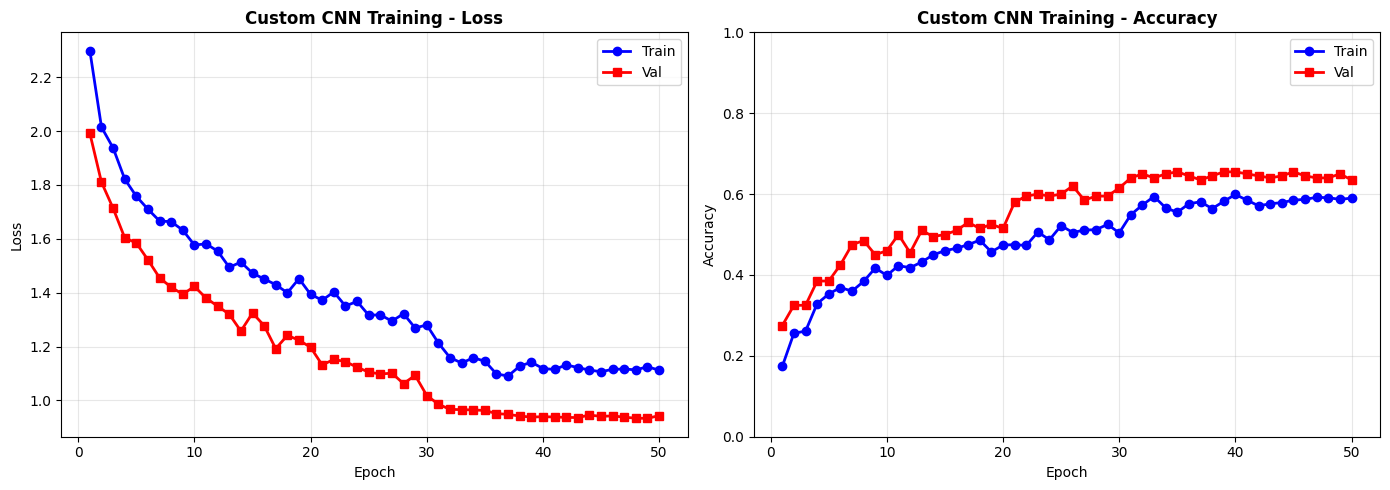


📊 Final Metrics (Custom CNN Training):
Train Acc: 0.5900
Val Acc:   0.6350
Best Val:  0.6550


In [ ]:
# Visualize custom CNN training
def plot_training_comparison(history, title="Custom CNN Training"):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

    # Print metrics
    print(f"\n📊 Final Metrics ({title}):")
    print("="*50)
    print(f"Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Val Acc:   {history['val_acc'][-1]:.4f}")
    print(f"Best Val:  {max(history['val_acc']):.4f}")

plot_training_comparison(custom_history)

---
## 📊 Section 4: Compare Models

Let's compare **Transfer Learning (ResNet50)** vs **Custom CNN**

In [ ]:
# Evaluate custom model on test set
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

custom_test_acc = evaluate_model(custom_model, dataloaders['test'])

print("🎯 Test Set Evaluation:")
print("="*70)
print(f"Custom CNN Test Accuracy: {custom_test_acc:.4f} ({custom_test_acc*100:.2f}%)")

🎯 Test Set Evaluation:
Custom CNN Test Accuracy: 0.5300 (53.00%)


In [ ]:
# Save model with comprehensive metadata
MODEL_PATH = '/content/cifar10_customCNN.pth'

# Create checkpoint
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': custom_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'history': custom_history,
    'best_val_acc': max(custom_history['val_acc']),
    'test_acc': custom_test_acc,
    'architecture': 'CustomCNN',
    'input_size': (32, 32),
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    }
}

# Save
torch.save(checkpoint, MODEL_PATH)

print(f"✅ Model saved to: {MODEL_PATH}")
print(f"📦 File size: {os.path.getsize(MODEL_PATH) / 1e6:.2f} MB")

print("\n📋 Checkpoint contains:")
print("   ✓ Model weights")
print("   ✓ Optimizer state")
print("   ✓ Scheduler state")
print("   ✓ Class names")
print("   ✓ Training history")
print("   ✓ Best validation accuracy")
print("   ✓ Test accuracy")
print("   ✓ Architecture info")
print("   ✓ Preprocessing params")

# Download model
from google.colab import files

print("\n📥 Downloading model...")
files.download(MODEL_PATH)
print("✅ Download complete!")

✅ Model saved to: /content/cifar10_customCNN.pth
📦 File size: 7.48 MB

📋 Checkpoint contains:
   ✓ Model weights
   ✓ Optimizer state
   ✓ Scheduler state
   ✓ Class names
   ✓ Training history
   ✓ Best validation accuracy
   ✓ Test accuracy
   ✓ Architecture info
   ✓ Preprocessing params

📥 Downloading model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete!


---
## 🌐 Section 5: Model Deployment with Gradio

Now let's deploy our **best model** (Transfer Learning ResNet50) as a web app!

In [ ]:
# Install Gradio
!pip install -q gradio

import gradio as gr

print("✅ Gradio installed!")
print(f"   Version: {gr.__version__}")

✅ Gradio installed!
   Version: 5.50.0


Resnet18 (TRANSFER LEARNING)

In [ ]:
def load_best_model():
    """
    Load the best performing model
    Priority: ResNet18 > Custom CNN
    """
    model_path = '/content/cifar10_resnet18.pth'

    # Try to load ResNet18
    if os.path.exists(model_path):
        print("📥 Loading ResNet18 from Part 1...")
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)  # 👈 Add this

        model = models.resnet18(pretrained=False)
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()

        print(f"   ✅ Loaded ResNet18")
        print(f"   Best Val Acc: {checkpoint.get('best_val_acc', 'N/A'):.4f}")
        return model, 224  # ResNet uses 224x224
    else:
        print("📥 Using Custom CNN (ResNet18 not found)")
        print(f"   Test Acc: {custom_test_acc:.4f}")
        return custom_model, 112  # Custom CNN uses 112x112

deployment_model, input_size = load_best_model()

📥 Loading ResNet18 from Part 1...
   ✅ Loaded ResNet18
   Best Val Acc: 0.6700


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


CustomCNN

In [ ]:
def load_best_model():
    """
    Load the best performing model
    Priority: Custom CNN > Currently trained model
    """
    model_path = '/content/cifar10_custom_cnn.pth'  # 👈 Changed path

    # Try to load Custom CNN checkpoint
    if os.path.exists(model_path):
        print("📥 Loading Custom CNN from checkpoint...")
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

        # Recreate the Custom CNN architecture
        model = CustomCNN(num_classes=num_classes)  # 👈 Use your CustomCNN class
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()

        print(f"   ✅ Loaded Custom CNN")
        print(f"   Best Val Acc: {checkpoint.get('best_val_acc', 'N/A'):.4f}")
        return model, 32  # Custom CNN uses 32x32
    else:
        print("📥 Using Custom CNN from current training session")
        print(f"   Test Acc: {custom_test_acc:.4f}")
        custom_model.eval()
        return custom_model, 32  # Custom CNN uses 32x32

deployment_model, input_size = load_best_model()

In [ ]:
# Create prediction function
def predict_object(image):
    """
    Predict object class from image

    Args:
        image: PIL Image or numpy array

    Returns:
        dict: {class_name: confidence}
    """
    # Preprocessing
    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Convert to PIL if needed
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Ensure RGB
    image = image.convert('RGB')

    # Transform and add batch dimension
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = deployment_model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

    # Create prediction dictionary
    predictions = {}
    for i, class_name in enumerate(class_names):
        predictions[class_name] = float(probabilities[0][i])

    return predictions

# Test prediction function
print("✅ Prediction function ready!")

✅ Prediction function ready!


In [ ]:
# Create Gradio interface
demo = gr.Interface(
    fn=predict_object,
    inputs=gr.Image(type="pil", label="Upload object Image"),
    outputs=gr.Label(num_top_classes=3, label="Predictions"),
    title="🍜 Cifar10 Classifier",
    description="Upload an image of Indonesian object to get predictions!",
    article="""
    ### 📊 Model Info
    - **Architecture**: ResNet18 (Transfer Learning) or Custom CNN

    ### 💡 Tips for Best Results:
    - Use clear, well-lit images
    - Object should be the main subject
    - Avoid heavily filtered images

    ### 👨‍🏫 Created by:
    Griffani Megiyanto - Politeknik Negeri Bandung
    """,
    examples=None,  # You can add example images here
    theme=gr.themes.Soft(),
    allow_flagging="never"
)

print("✅ Gradio interface created!")

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


✅ Gradio interface created!


In [ ]:
# Launch the app!
print("🚀 Launching Gradio app...\n")
print("📝 Instructions:")
print("   1. Click the link below to open the app")
print("   2. Upload an object")
print("   3. View predictions with confidence scores")
print("   4. Share the public link with others!\n")

# Launch with share=True to get public link
demo.launch(
    share=True,      # Creates public shareable link
    debug=False,
    show_error=True
)

print("\n✅ App is running!")
print("\n💡 Public link will expire in 72 hours")
print("💡 Anyone with the link can use your model!")

🚀 Launching Gradio app...

📝 Instructions:
   1. Click the link below to open the app
   2. Upload an object
   3. View predictions with confidence scores
   4. Share the public link with others!

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8e8be842bc232716a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ App is running!

💡 Public link will expire in 72 hours
💡 Anyone with the link can use your model!


### 💡 Production Deployment Tips

**1. Model Optimization:**
```python
# Quantization (reduce size by ~4x)
quantized_model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

# TorchScript (faster inference)
scripted_model = torch.jit.script(model)
scripted_model.save('model_scripted.pt')

# ONNX (cross-platform)
torch.onnx.export(
    model, dummy_input, 'model.onnx',
    input_names=['image'], output_names=['predictions']
)
```

**2. Deployment Platforms:**
- 🌐 **Gradio on HuggingFace Spaces** (Free, persistent)
- ☁️ **AWS Lambda + API Gateway** (Serverless)
- 🐳 **Docker + FastAPI** (Full control)
- 📱 **Mobile: TensorFlow Lite / PyTorch Mobile**

**3. Performance Monitoring:**
- Track inference time
- Log predictions and confidences
- Monitor accuracy on production data
- Set up A/B testing for model updates

**4. Best Practices:**
- ✅ Add input validation
- ✅ Implement error handling
- ✅ Set confidence thresholds
- ✅ Version your models
- ✅ Monitor resource usage

---